## Library import

In [ ]:
import ember
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

EMBER_PATH = "../data/raw/ember2018"

## Load the dataset

In [22]:
X_train, y_train, X_test, y_test = ember.read_vectorized_features(EMBER_PATH)

# Filter only labled sample from the dataset
mask = y_train != -1
X_labled = X_train[mask]
y_labled = y_train[mask]

print(f"Labled samples: {X_labled.shape}")
print(f"Features per samples: {y_labled.shape}")
print(f"Benign:  {(y_labled == 0).sum()}")
print(f"Malware:  {(y_labled == 1).sum()}")

Labled samples: (600000, 2381)
Features per samples: (600000,)
Benign:  300000
Malware:  300000


## Lable distribution

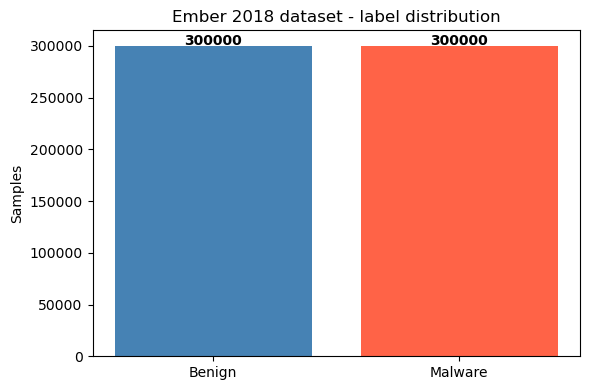

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Benign", "Malware"]
counts = [(y_labled == 0).sum(), (y_labled == 1).sum()]
ax.bar(labels, counts, color=["steelblue", "tomato"])
ax.set_title("Ember 2018 dataset - label distribution")
ax.set_ylabel("Samples")
for i, v in enumerate(counts):
    ax.text(i, v + 1000, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("../experiments/label_distribution.png", dpi=150)
plt.show()

## Features statistics

In [24]:
n_features = 2000
df = pd.DataFrame(X_labled[:n_features])
print(f"Statistics on {n_features} features:\n")
print(df.describe().round(3))

Statistics on 2000 features:

           0         1         2         3         4         5         6     \
count  2000.000  2000.000  2000.000  2000.000  2000.000  2000.000  2000.000   
mean      0.309     0.012     0.006     0.006     0.011     0.004     0.003   
std       0.194     0.009     0.013     0.014     0.027     0.012     0.007   
min       0.004     0.000     0.000     0.000     0.000     0.000     0.000   
25%       0.171     0.007     0.004     0.003     0.004     0.002     0.002   
50%       0.264     0.010     0.005     0.004     0.007     0.003     0.003   
75%       0.459     0.014     0.007     0.006     0.010     0.004     0.004   
max       0.925     0.097     0.425     0.229     0.387     0.266     0.234   

           7         8         9     ...      2371         2372      2373  \
count  2000.000  2000.000  2000.000  ...  2000.000     2000.000  2000.000   
mean      0.003     0.007     0.002  ...    13.324    47669.156    14.570   
std       0.003     0.005  

## Features distribution per class

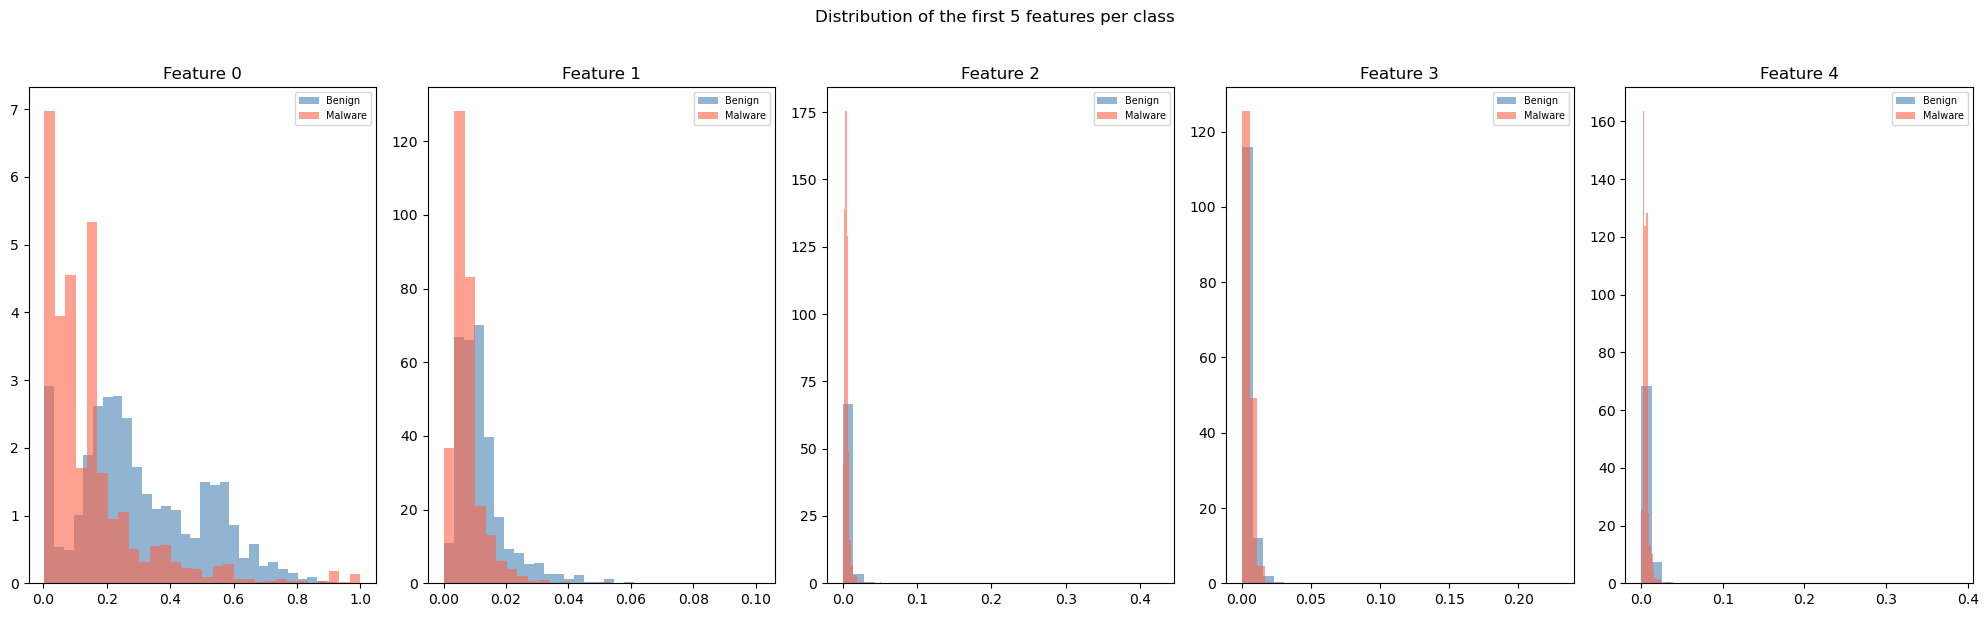

In [25]:
# compare between the first 10 features fo benign and malware
n_features = 5
fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 6))
if n_features == 1:
    axes = [axes]  # wrap it so the loop still works
axes.flatten()

X_ben = X_labled[y_labled == 0][:2000]
X_mal = X_labled[y_labled == 1][:2000]

for i, ax in enumerate(axes):
    ax.hist(X_ben[:, i], bins=30, alpha=0.6,
            color="steelblue", label="Benign", density=True)
    ax.hist(X_mal[:, i], bins=30, alpha=0.6,
            color="tomato", label="Malware", density=True)
    ax.set_title(f"Feature {i}")
    ax.legend(fontsize=7)

plt.suptitle(f"Distribution of the first {n_features} features per class", y=1.02)
plt.tight_layout()
plt.savefig("../experiments/feature_distributions.png", dpi=150)
plt.show()